## Exploratory demo of the BART/NLINV baseline reconstruction for simulated phantom data

This notebook prepares baseline reconstructions for the simulated phantom experiment using the
[BART: Berkeley Advanced Reconstruction Toolbox](https://mrirecon.codeberg.page/). The main BART
commands used here are `poisson` for variable-density undersampling masks, `fmac` for applying masks
to k-space data, `rss` for root-sum-of-squares coil combination, and `nlinv` for nonlinear inverse
reconstruction.

The phantom data used here are generated separately by the MATLAB script
`data/phantom/Exp3_generate_phantom_data.m`. This notebook assumes the following files are already
available:

- `data/phantom/phantom.mat`
- `data/phantom/slice_full_v2_noviolation.mat`
- `data/phantom/pat.mat`

The final baseline reconstructions are saved to:

- `output/phantom/ENLIVE_phantom.mat`

References:
- BART toolbox: Uecker et al., *Berkeley Advanced Reconstruction Toolbox*, ISMRM 2015.
- ENLIVE/NLINV-style calibrationless reconstruction: Holme et al.,
  *ENLIVE: An Efficient Nonlinear Method for Calibrationless and Robust Parallel Imaging*,
  Scientific Reports 9, 3034 (2019).

Note: this notebook is intended as an archived preprocessing/baseline-generation record. It requires
a working local BART installation to rerun.

In [ ]:
import os
import sys
os.environ['BART_TOOLBOX_PATH'] = '../bart' # Set the path to the BART toolbox
sys.path.append('../bart/python')

In [2]:
import bart
import cfl
import matplotlib.pyplot as plt
import numpy as np
import scipy.io

In [ ]:
def disp(im, figsize=(4,4)): 
    """Display the magnitude of a possibly complex-valued image array."""
    _, ax = plt.subplots(figsize=figsize)
    ax.set_xticks([0, im.shape[0]-1])
    ax.set_yticks([0, im.shape[1]-1])
    ax.imshow(abs(np.squeeze(im)), cmap='gray')

In [ ]:
# Load the simulated phantom ground truth and full multi-coil k-space data.
# `slice_full_v2_noviolation.mat` contains k-space generated from the fitted coil model
truth = scipy.io.loadmat('data/phantom/phantom')['im']
phantom = scipy.io.loadmat('data/phantom/slice_full_v2_noviolation') #zero frequency first, no model violation
slice_full = np.fft.fftshift(phantom['slice_full'])[np.newaxis,:,:]

In [ ]:
# BART uses arrays with explicit dimensions. Here the last dimension is coil.
print(slice_full.shape)
nc = slice_full.shape[3]

(1, 256, 256, 8)


In [ ]:
# Optional: save converted arrays if needed for MATLAB/Python interoperability.
#from scipy.io import savemat
# Save the NumPy array to a .mat file
#savemat('slice-full.mat', {'data': brain})

In [94]:
print(slice_full.dtype)

complex128


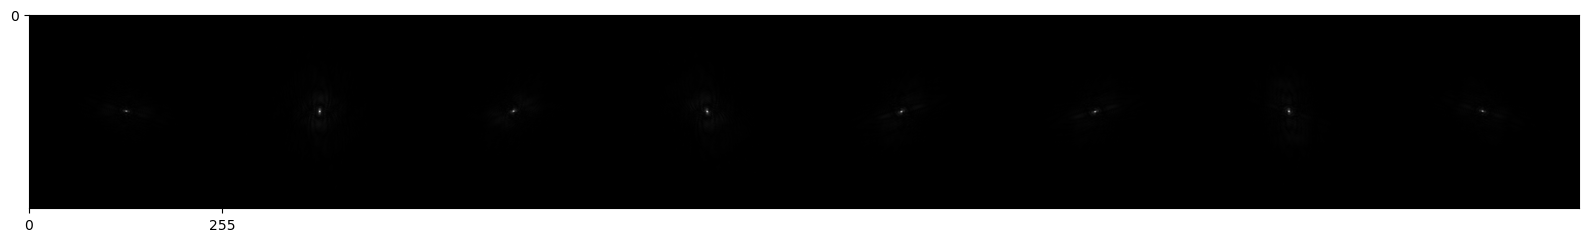

In [ ]:
# Visualize the magnitude of the full k-space data for all coils.
disp(np.concatenate([slice_full[0,:,:,i] for i in range(nc)], 1), figsize=(20,10))

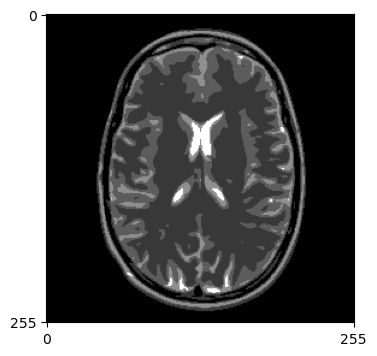

In [ ]:
# Visualize the phantom ground truth.
disp(truth)

## Sampling masks

This section demonstrates how to use BART `poisson` command to generate the variable-density masks. The random seed is fixed for reproducibility.

In [8]:
nc =slice_full.shape[3]

In [161]:
tmp_rss = bart.bart(1,'rss 8', slice_full)

In [370]:
#tmp_rss = bart.bart(1,'rss 8',phantom)
tmp_pat = bart.bart(1,'threshold -H 0.3', tmp_rss)
pat = bart.bart(1,'pattern',tmp_pat)

In [ ]:
#The BART commands can be inspected from a terminal with, for example,
!bart threshold -h

WARN: BART version v0.9.00-466-gb3be61a-dirty is not reproducible.
Usage: threshold [-H] [-W] [-L] [-D] [-B] [-M] [-j d] [-b d] lambda <input> <output> 

Perform (soft) thresholding with parameter lambda.

-H              hard thresholding
-W              daubechies wavelet soft-thresholding
-L              locally low rank soft-thresholding
-D              divergence-free wavelet soft-thresholding
-B              thresholding with binary output where (val>lambda)
-M              thresholding with binary output where (val<lambda)
-j bitmask      joint soft-thresholding
-b blocksize    locally low rank block size
-h              help


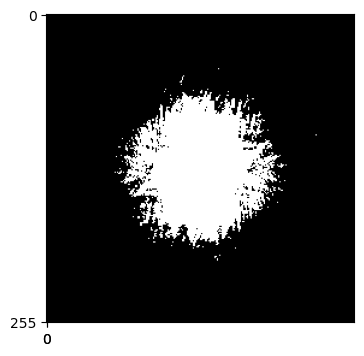

In [ ]:
#display the sampling pattern
disp(pat)

### Poisson undersampling masks

The comments below record the BART `poisson` settings used to generate masks with different
approximate sampling rates.

The variables US and V below are BART `poisson` parameters, not exactly equal to the final reduction factor. 
Below is the approximate correspondence between US and V versus sampling rate:

US = 1.19,V -05, ~ 1/3 sampling 

US = 1.53,V -05, ~ 1/4 sampling

US = 1.84,V -05, ~ 1/5 sampling

US = 1, V -25, ~ 1/9 sampling

US = 1.4, V -25, ~ 1/10 sampling

US = 2.65, V -25, ~ 1/15 sampling

US = 3.45, V -25, ~ 1/20 sampling

In [50]:
SEED = 20869

In [ ]:
# Example BART Poisson mask generation for pat_4.
US = 1.53
US_1 = US 
US_2 = US 
pat_4 = bart.bart(1,'poisson -Y 256 -Z 256 -y {} -z {} -v -V 05 -s {} -C 1'.format(US_1,US_2,SEED))
#pat_2 = bart.bart(1,'fmac',tmp_pat_2,pat)

points: 16428, grid size: 256x256 = 65536 (R = 3.989287)


In [ ]:
US = 1.84
US_1 = US 
US_2 = US 
pat_5 = bart.bart(1,'poisson -Y 256 -Z 256 -y {} -z {} -v -V 05 -s {} -C 3'.format(US_1,US_2,SEED))
#pat_2 = bart.bart(1,'fmac',tmp_pat_2,pat)

points: 13037, grid size: 256x256 = 65536 (R = 5.026923)


In [ ]:
US = 1
US_1 = US 
US_2 = US 
pat_9 = bart.bart(1,'poisson -Y 256 -Z 256 -y {} -z {} -v -V 25 -s {} -C 3'.format(US_1,US_2,SEED))
#pat_2 = bart.bart(1,'fmac',tmp_pat_2,pat)

points: 7256, grid size: 256x256 = 65536 (R = 9.031974)


In [ ]:
US = 2.62
US_1 = US 
US_2 = US 
pat_15 = bart.bart(1,'poisson -Y 256 -Z 256 -y {} -z {} -v -V 25 -s {} -C 3'.format(US_1,US_2,SEED))
#pat_2 = bart.bart(1,'fmac',tmp_pat_2,pat)

points: 4371, grid size: 256x256 = 65536 (R = 14.993365)


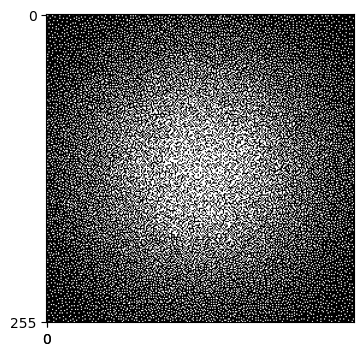

In [ ]:
# Visualize pat_3 mask
disp(pat_3)

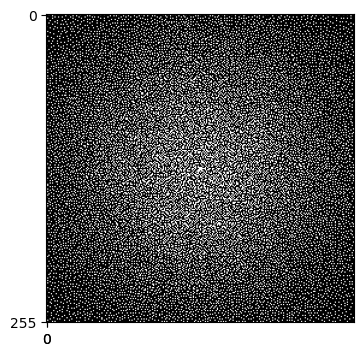

In [392]:
disp(pat_4)

In [ ]:
disp(pat_5)

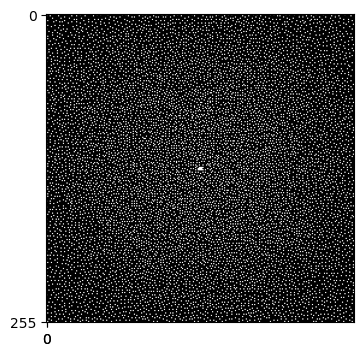

In [313]:
disp(pat_7)

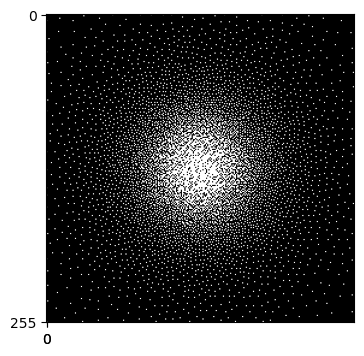

In [327]:
disp(pat_9)

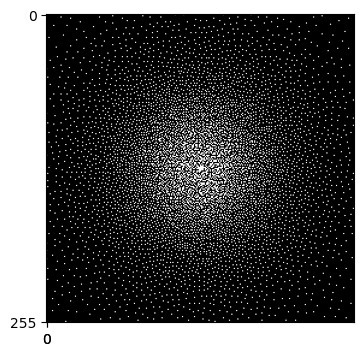

In [332]:
disp(pat_10)

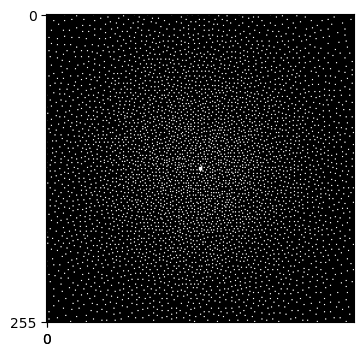

In [346]:
disp(pat_15)

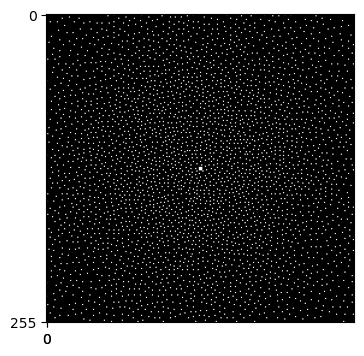

In [393]:
disp(pat_20)

In [ ]:
#from scipy.io import savemat
#savemat('../data/phantom/pat.mat',{'pat_3':pat_3,'pat_4':pat_4,'pat_5':pat_5,'pat_10':pat_10, 'pat_15':pat_15,'pat_20':pat_20})

In [ ]:
# Optional: load the masks used in the reconstruction experiments.
pat = scipy.io.loadmat('../data/phantom/pat')
pat_4 = scipy.io.loadmat('data/phantom/pat_4')['pat_4']

## Zero-filled / RSS reference reconstruction
This section computes a simple averaged inverse-FFT reference reconstruction from zero-filling k-space data.

In [ ]:
# Coil-wise inverse FFT of the full k-space data.
test = np.fft.ifft2(slice_full,axes = (1,2))

BART `rss` computes a root-sum-of-squares coil combination. This gives a simple fully sampled
reference image, not a calibrationless reconstruction.

In [10]:
!bart rss -h

zsh:1: command not found: bart


In [11]:
print(test.shape)
test_recon = bart.bart(1,'rss 8', test)
print(test_recon.shape)

(1, 256, 256, 8)
(1, 256, 256)


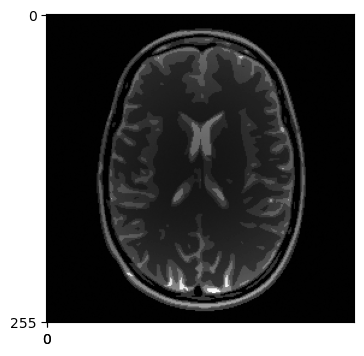

In [12]:
disp(test_recon)

## BART NLINV / ENLIVE-style baseline reconstruction

The following cells use BART's `nlinv` command to compute calibrationless nonlinear inverse
reconstructions for the full and undersampled phantom k-space data. The settings are kept close
to the original exploratory BART baseline used for comparison.

In [ ]:
#For command-line details, run `bart nlinv -h` in a terminal with BART installed.
!bart nlinv -h

WARN: BART version v0.9.00-466-gb3be61a-dirty is not reproducible.
Usage: nlinv [-i d] [-d d] [-c] [-N] [-m d] [-U] [-f f] [-p <file>] [-t <file>] [-B <file>] [-I <file>] [-g] [-S] [--lowmem] [-x,--dims d:d:d] [--sens-dims d:d:d] [--real-time] [--fast] <kspace> <output> [<sensitivities>] 

Jointly estimate image and sensitivities with nonlinear
inversion using {iter} iteration steps. Optionally outputs
the sensitivities.

-i iter              Number of Newton steps
-d level             Debug level
-c                   Real-value constraint
-N                   Do not normalize image with coil sensitivities
-m nmaps             Number of ENLIVE maps to use in reconstruction
-U                   Do not combine ENLIVE maps in output
-f FOV               restrict FOV
-p file              pattern / transfer function
-t file              kspace trajectory
-B file              temporal (or other) basis
-I file              File for initialization
-g                   use gpu
-S               

In [15]:
ENLINV_0 = bart.bart(1, 'nlinv -d 4 -m 2 -a 240 -b 40 -i 11 -R 2 -S', slice_full)


Model created (Cartesian):
kspace:  [  1 256 256   8   1   1   1   1   1   1   1   1   1   1   1   1 ]
images:  [  1 256 256   1   2   1   1   1   1   1   1   1   1   1   1   1 ]
coils:   [  1 256 256   8   2   1   1   1   1   1   1   1   1   1   1   1 ]
pattern: [  1 256 256   1   1   1   1   1   1   1   1   1   1   1   1   1 ]
coilimg: [  1 256 256   8   1   1   1   1   1   1   1   1   1   1   1   1 ]

Scaling: 23.574263
Step: 0, Res: 99.999997
	 cg:   0
Step: 1, Res: 83.683477
	 cg:   0
Step: 2, Res: 67.382750
	 cg:   3
Step: 3, Res: 48.315282
	 cg:   7
Step: 4, Res: 29.518171
	 cg:   8
Step: 5, Res: 15.648367
	 cg:  16
Step: 6, Res: 9.201506
	 cg:  20
Step: 7, Res: 7.103580
	 cg:  51
Step: 8, Res: 3.337285
	 cg:  83
Step: 9, Res: 1.160342
	 cg:  72
Step: 10, Res: 0.615927
	 cg:  70
Total time: 15.20 s


### Compare BART NLINV reconstruction with RSS reference

0.0025959709


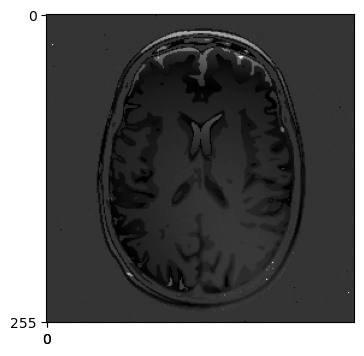

In [16]:
im1 = np.fft.fftshift(ENLINV_0)
scale = np.vdot(im1,test_recon)/np.vdot(im1,im1)
disp(im1 * scale - test_recon)
print(np.linalg.norm(im1 * scale - test_recon)/np.linalg.norm(test_recon))

(1.505599042726823+0j)
0.43366421127810495


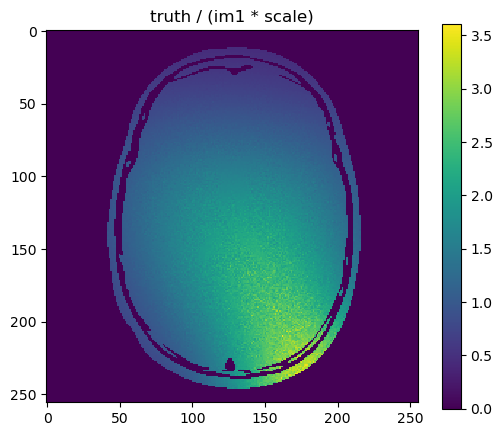

In [17]:
# Calculate the result of truth / (im1 * scale)
scale = np.vdot(im1,truth)/np.vdot(im1,im1)
result = truth / (im1 * scale).squeeze()
print(np.mean(result[result!=0]))
print(np.linalg.norm(im1.flatten() * scale - truth.flatten())/np.linalg.norm(truth.flatten()))
# Plotting
plt.figure(figsize=(6, 5))
img = plt.imshow(abs(result), cmap='viridis', interpolation='none')
plt.colorbar(img)  # Add colorbar
plt.title('truth / (im1 * scale)')
plt.show()

### Additional undersampling factors

The following cells repeat the same BART `fmac` + `nlinv` baseline workflow for the remaining
sampling masks.

In [53]:
pat_3 = pat['pat_3']
phantom_3 = bart.bart(1,'fmac',slice_full,pat_3)
print(phantom_3.shape)

(1, 256, 256, 8)


In [16]:
ENLINV_3 = bart.bart(1, 'nlinv -d 4 -m 2 -a 240 -b 40 -i 11 -R 2 -S', phantom_3)


Model created (Cartesian):
kspace:  [  1 256 256   8   1   1   1   1   1   1   1   1   1   1   1   1 ]
images:  [  1 256 256   1   2   1   1   1   1   1   1   1   1   1   1   1 ]
coils:   [  1 256 256   8   2   1   1   1   1   1   1   1   1   1   1   1 ]
pattern: [  1 256 256   1   1   1   1   1   1   1   1   1   1   1   1   1 ]
coilimg: [  1 256 256   8   1   1   1   1   1   1   1   1   1   1   1   1 ]

Scaling: 224.721573
Step: 0, Res: 100.000001
	 cg:   0
Step: 1, Res: 93.079888
	 cg:   0
Step: 2, Res: 94.443178
	 cg:   0
Step: 3, Res: 83.401374
	 cg:   1
Step: 4, Res: 51.096433
	 cg:   1
Step: 5, Res: 21.393608
	 cg:   4
Step: 6, Res: 8.963706
	 cg:   8
Step: 7, Res: 5.130906
	 cg:  13
Step: 8, Res: 3.521767
	 cg:  23
Step: 9, Res: 2.915039
	 cg:  42
Step: 10, Res: 2.688688
	 cg:  79
Total time: 18.06 s


0.2789962301716018


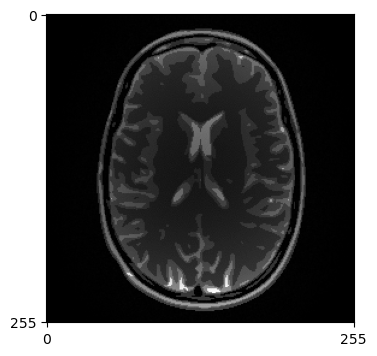

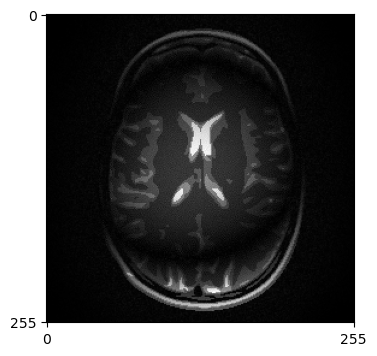

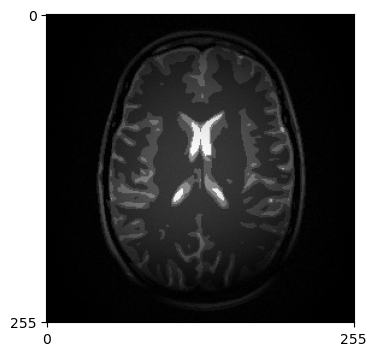

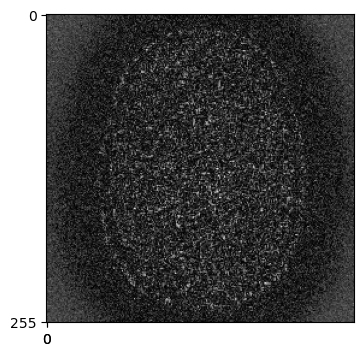

In [17]:
im1 = np.squeeze(np.fft.fftshift(ENLINV_3))
scale = np.vdot(im1,truth)/np.vdot(im1,im1)
print(np.linalg.norm(im1 * scale - truth,'fro')/np.linalg.norm(truth,'fro'))
disp(im1 * scale)
disp(im1 * scale - truth)
disp(im1/np.max(im1) - truth)
scale = np.vdot(im1,test_recon)/np.vdot(im1,im1)
disp(im1 * scale - test_recon)

In [86]:
ENLINV_3 = bart.bart(1, 'nlinv -d 4 -m 1 -a 240 -b 40 -i 11 -S', phantom_3)


Model created (Cartesian):
kspace:  [  1 256 256   8   1   1   1   1   1   1   1   1   1   1   1   1 ]
images:  [  1 256 256   1   1   1   1   1   1   1   1   1   1   1   1   1 ]
coils:   [  1 256 256   8   1   1   1   1   1   1   1   1   1   1   1   1 ]
pattern: [  1 256 256   1   1   1   1   1   1   1   1   1   1   1   1   1 ]
coilimg: [  1 256 256   8   1   1   1   1   1   1   1   1   1   1   1   1 ]

Scaling: 168.220520
Step: 0, Res: 100.000000
	 cg:   0
Step: 1, Res: 96.024190
	 cg:   0
Step: 2, Res: 95.406955
	 cg:   0
Step: 3, Res: 83.679268
	 cg:   1
Step: 4, Res: 52.219209
	 cg:   1
Step: 5, Res: 23.574500
	 cg:   4
Step: 6, Res: 9.099044
	 cg:  10
Step: 7, Res: 5.191388
	 cg:  14
Step: 8, Res: 3.558080
	 cg:  26
Step: 9, Res: 2.944303
	 cg:  44
Step: 10, Res: 2.714682
	 cg:  76
Total time: 11.52 s


0.32747261804569056


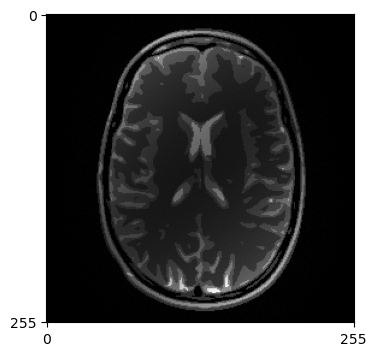

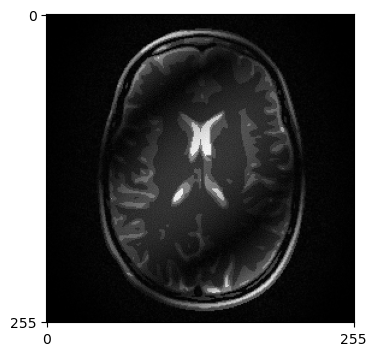

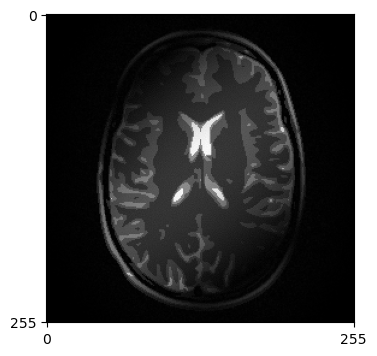

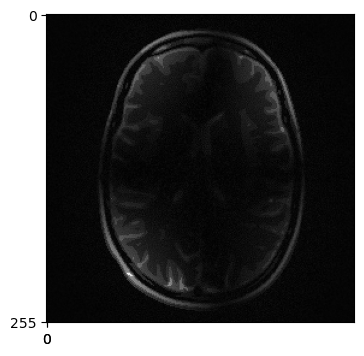

In [87]:
im1 = np.squeeze(np.fft.fftshift(ENLINV_3))
scale = np.vdot(im1,truth)/np.vdot(im1,im1)
print(np.linalg.norm(im1 * scale - truth,'fro')/np.linalg.norm(truth,'fro'))
disp(im1 * scale)
disp(im1 * scale - truth)
disp(im1/np.max(im1) - truth)
scale = np.vdot(im1,test_recon)/np.vdot(im1,im1)
disp(im1 * scale - test_recon)

In [56]:
pat_4 = pat['pat_4']
phantom_4 = bart.bart(1,'fmac',slice_full,pat_4)
ENLINV_4 = bart.bart(1, 'nlinv -d 4 -m 2 -a 240 -b 40 -i 11 -S', phantom_4)


Model created (Cartesian):
kspace:  [  1 256 256   8   1   1   1   1   1   1   1   1   1   1   1   1 ]
images:  [  1 256 256   1   2   1   1   1   1   1   1   1   1   1   1   1 ]
coils:   [  1 256 256   8   2   1   1   1   1   1   1   1   1   1   1   1 ]
pattern: [  1 256 256   1   1   1   1   1   1   1   1   1   1   1   1   1 ]
coilimg: [  1 256 256   8   1   1   1   1   1   1   1   1   1   1   1   1 ]

Scaling: 179.149994
Step: 0, Res: 100.000000
	 cg:   0
Step: 1, Res: 91.711890
	 cg:   0
Step: 2, Res: 93.739687
	 cg:   0
Step: 3, Res: 82.044562
	 cg:   1
Step: 4, Res: 51.134455
	 cg:   1
Step: 5, Res: 23.706909
	 cg:   4
Step: 6, Res: 10.424043
	 cg:   9
Step: 7, Res: 5.631117
	 cg:  14
Step: 8, Res: 3.622116
	 cg:  25
Step: 9, Res: 2.788444
	 cg:  43
Step: 10, Res: 2.455751
	 cg:  72
Total time: 24.22 s


0.3189356931893586


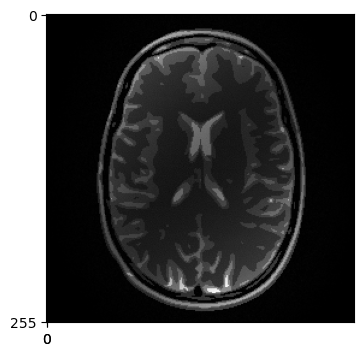

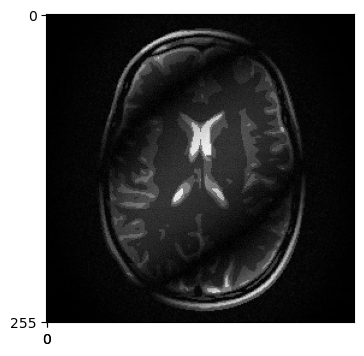

In [57]:
im1 = np.fft.fftshift(ENLINV_4)
scale = np.vdot(im1,truth)/np.vdot(im1,im1)
print(np.linalg.norm(im1 * scale - truth)/np.linalg.norm(truth))
disp(im1 * scale)
disp(im1 * scale - truth)

In [78]:
pat_5 = pat['pat_5']
phantom_5 = bart.bart(1,'fmac',slice_full,pat_5)
ENLINV_5 = bart.bart(1, 'nlinv -d 4 -m 2 -a 240 -b 40 -i 11', phantom_5)


Model created (Cartesian):
kspace:  [  1 256 256   8   1   1   1   1   1   1   1   1   1   1   1   1 ]
images:  [  1 256 256   1   2   1   1   1   1   1   1   1   1   1   1   1 ]
coils:   [  1 256 256   8   2   1   1   1   1   1   1   1   1   1   1   1 ]
pattern: [  1 256 256   1   1   1   1   1   1   1   1   1   1   1   1   1 ]
coilimg: [  1 256 256   8   1   1   1   1   1   1   1   1   1   1   1   1 ]

Scaling: 186.597290
Step: 0, Res: 99.999997
	 cg:   0
Step: 1, Res: 90.683358
	 cg:   0
Step: 2, Res: 93.144917
	 cg:   0
Step: 3, Res: 80.874014
	 cg:   0
Step: 4, Res: 50.237023
	 cg:   2
Step: 5, Res: 24.598981
	 cg:   5
Step: 6, Res: 11.426326
	 cg:  10
Step: 7, Res: 6.063880
	 cg:  14
Step: 8, Res: 3.735580
	 cg:  24
Step: 9, Res: 2.690183
	 cg:  41
Step: 10, Res: 2.236365
	 cg:  70
Total time: 24.57 s


0.3199243183610194


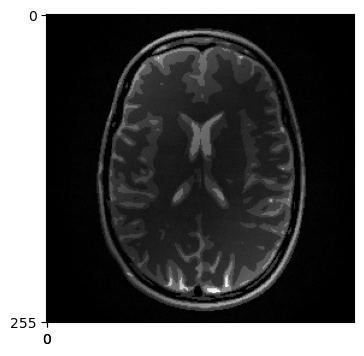

In [79]:
im1 = np.fft.fftshift(ENLINV_5)
scale = np.vdot(im1,truth)/np.vdot(im1,im1)
print(np.linalg.norm(im1 * scale - truth)/np.linalg.norm(truth))
disp(np.fft.fftshift(ENLINV_5))

In [80]:
pat_10 = pat['pat_10']
phantom_10 = bart.bart(1,'fmac',slice_full,pat_10)
ENLINV_10 = bart.bart(1, 'nlinv -d 4 -m 2 -a 240 -b 40 -i 11 -S', phantom_10)


Model created (Cartesian):
kspace:  [  1 256 256   8   1   1   1   1   1   1   1   1   1   1   1   1 ]
images:  [  1 256 256   1   2   1   1   1   1   1   1   1   1   1   1   1 ]
coils:   [  1 256 256   8   2   1   1   1   1   1   1   1   1   1   1   1 ]
pattern: [  1 256 256   1   1   1   1   1   1   1   1   1   1   1   1   1 ]
coilimg: [  1 256 256   8   1   1   1   1   1   1   1   1   1   1   1   1 ]

Scaling: 176.755692
Step: 0, Res: 99.999999
	 cg:   0
Step: 1, Res: 91.769741
	 cg:   0
Step: 2, Res: 93.332372
	 cg:   0
Step: 3, Res: 80.724801
	 cg:   1
Step: 4, Res: 49.242118
	 cg:   1
Step: 5, Res: 23.109784
	 cg:   4
Step: 6, Res: 10.061120
	 cg:  10
Step: 7, Res: 5.196741
	 cg:  14
Step: 8, Res: 3.039646
	 cg:  25
Step: 9, Res: 2.042516
	 cg:  43
Step: 10, Res: 1.602951
	 cg:  72
Total time: 24.67 s


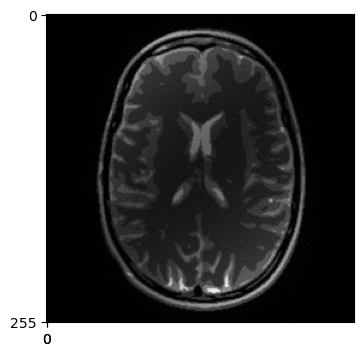

In [81]:
disp(np.fft.fftshift(ENLINV_10))

In [82]:
pat_15 = pat['pat_15']
phantom_15 = bart.bart(1,'fmac',slice_full,pat_15)
ENLINV_15 = bart.bart(1, 'nlinv -d 4 -m 2 -a 240 -b 40 -i 11 -S', phantom_15)


Model created (Cartesian):
kspace:  [  1 256 256   8   1   1   1   1   1   1   1   1   1   1   1   1 ]
images:  [  1 256 256   1   2   1   1   1   1   1   1   1   1   1   1   1 ]
coils:   [  1 256 256   8   2   1   1   1   1   1   1   1   1   1   1   1 ]
pattern: [  1 256 256   1   1   1   1   1   1   1   1   1   1   1   1   1 ]
coilimg: [  1 256 256   8   1   1   1   1   1   1   1   1   1   1   1   1 ]

Scaling: 196.052612
Step: 0, Res: 99.999998
	 cg:   0
Step: 1, Res: 89.165299
	 cg:   0
Step: 2, Res: 92.005150
	 cg:   0
Step: 3, Res: 77.717410
	 cg:   0
Step: 4, Res: 46.682236
	 cg:   3
Step: 5, Res: 23.030413
	 cg:   5
Step: 6, Res: 11.270281
	 cg:  10
Step: 7, Res: 6.084364
	 cg:  15
Step: 8, Res: 3.555895
	 cg:  25
Step: 9, Res: 2.244823
	 cg:  41
Step: 10, Res: 1.560817
	 cg:  70
Total time: 24.99 s


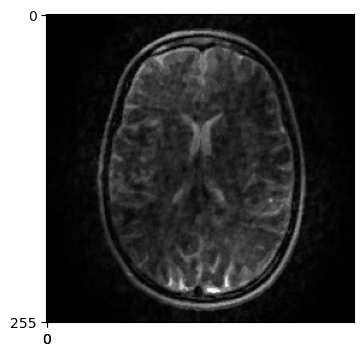

In [83]:
im1 = np.fft.fftshift(ENLINV_15)
disp(im1)

In [84]:
pat_20 = pat['pat_20']
phantom_20 = bart.bart(1,'fmac',slice_full,pat_20)
ENLINV_20 = bart.bart(1, 'nlinv -d 4 -m 2 -a 240 -b 40 -i 11 -S', phantom_20)


Model created (Cartesian):
kspace:  [  1 256 256   8   1   1   1   1   1   1   1   1   1   1   1   1 ]
images:  [  1 256 256   1   2   1   1   1   1   1   1   1   1   1   1   1 ]
coils:   [  1 256 256   8   2   1   1   1   1   1   1   1   1   1   1   1 ]
pattern: [  1 256 256   1   1   1   1   1   1   1   1   1   1   1   1   1 ]
coilimg: [  1 256 256   8   1   1   1   1   1   1   1   1   1   1   1   1 ]

Scaling: 200.842194
Step: 0, Res: 99.999999
	 cg:   0
Step: 1, Res: 88.474092
	 cg:   0
Step: 2, Res: 91.323055
	 cg:   0
Step: 3, Res: 75.801342
	 cg:   0
Step: 4, Res: 43.753616
	 cg:   3
Step: 5, Res: 22.124559
	 cg:   5
Step: 6, Res: 10.577522
	 cg:  11
Step: 7, Res: 5.703713
	 cg:  17
Step: 8, Res: 3.396574
	 cg:  25
Step: 9, Res: 2.122171
	 cg:  42
Step: 10, Res: 1.397764
	 cg:  61
Total time: 24.61 s


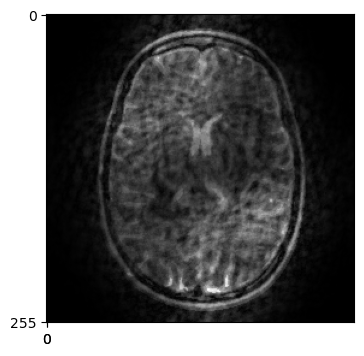

In [85]:
disp(np.fft.fftshift(ENLINV_20))

Save BART baseline reconstructions for later comparison with the proposed l1,2 method.

In [ ]:
from scipy.io import savemat
savemat('../output/phantom/ENLIVE_phantom.mat', {'phantom_3': ENLINV_3,'phantom_4': ENLINV_4,'phantom_5': ENLINV_5,'phantom_10': ENLINV_10,'phantom_15': ENLINV_15,'phantom_20': ENLINV_20})